# Analisi Stress Relaxation — versione essenziale

Questo notebook è stato ridotto a **4 celle operative**:

1. **import librerie**;
2. **impostazione input** (`data_dir` + opzioni principali);
3. **caricamento/preprocessing automatico**;
4. **analisi completa** con fit, grafici ed export.

**Uso rapido:** imposta `data_dir` nella cella 2 ed esegui le celle in ordine dall'alto verso il basso.

In [16]:
# 1. Import librerie
import sys
sys.path.insert(0, r'/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo')

import os
import json
import shutil
import tempfile
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from pyfmreader import loadfile

try:
    from sklearn.metrics import r2_score
except Exception:
    def r2_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [ ]:
# 2. Input da analizzare
#
# Puoi passare direttamente:
#   - una CARTELLA con le curve SR grezze `.jpk-force`
#   - oppure un file singolo gia pronto (`*-media-norm.csv`, `.jpk-force`, ecc.)
#
# Se passi una cartella, il notebook:
#   1) genera automaticamente la curva media normalizzata
#   2) salva `*-media-norm.csv`
#   3) esegue subito tutti i fit su quel file medio

data_dir = r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR"
input_force_mode = "auto"   # "auto" | "raw" | "normalized"
normalized_reference = "Fpicco,init"

# Parametri usati solo se `data_dir` e' una cartella
num_curves = None            # None = usa tutte le curve SR trovate nella cartella
segment_index = None         # None = usa automaticamente il segmento pause/dwell
normalization_mode = "peak" # "peak" | "first" | "mean"
reference_points = 200       # punti iniziali usati per stimare Fpicco,init
outlier_sigma = 3.5          # filtro robusto tra curve durante la media
min_valid_curves = 2         # minimo numero di curve concordi per tenere un punto
save_preprocessed_mean = True

# Parametri opzionali per stimare E_ref (Hertz) dal grezzo .jpk-force
tip_geometry = "sphere"      # "sphere" (consigliato)
tip_radius_um = 2.5          # raggio punta in um (usato se tip_geometry='sphere')
poisson_ratio = 0.5          # coefficiente di Poisson del campione
hertz_fit_fraction = 0.3     # frazione iniziale della fase di contatto usata nel fit

# Opzioni finali di output
save_outputs = True
open_output_folder = False  # se True apre direttamente il PDF finale (fallback: cartella)



In [18]:
# 3. Workflow unificato: preparazione automatica, caricamento e preprocessing

def make_odd(value):
    value = max(3, int(value))
    return value if value % 2 == 1 else value + 1


def smooth_signal(signal, window):
    signal = np.asarray(signal, dtype=np.float32)
    if len(signal) < 5:
        return signal.copy()

    max_window = len(signal) if len(signal) % 2 == 1 else len(signal) - 1
    window = min(make_odd(window), max_window)
    if window < 5:
        return signal.copy()

    pad = window // 2
    kernel = np.ones(window, dtype=np.float32) / window
    padded = np.pad(signal, (pad, pad), mode="edge")
    return np.convolve(padded, kernel, mode="valid").astype(np.float32)


def robust_inlier_mask(values, z_thresh=3.5):
    values = np.asarray(values, dtype=np.float32)
    valid = np.isfinite(values)

    if values.ndim != 2 or values.shape[0] < 3 or z_thresh is None or z_thresh <= 0:
        return valid

    median = np.nanmedian(values, axis=0)
    abs_dev = np.abs(values - median)
    mad = np.nanmedian(abs_dev, axis=0)
    robust_sigma = 1.4826 * mad
    std_sigma = np.nanstd(values, axis=0)

    spread = np.where(
        np.isfinite(robust_sigma) & (robust_sigma > 1e-12),
        robust_sigma,
        np.where(np.isfinite(std_sigma) & (std_sigma > 1e-12), std_sigma, np.nan),
    )

    with np.errstate(divide='ignore', invalid='ignore'):
        robust_z = abs_dev / spread

    return valid & ((robust_z <= z_thresh) | ~np.isfinite(robust_z))


def get_force_curve_and_segment(file_path, segment_index=None):
    afm_file = loadfile(file_path)
    force_curve = afm_file.getcurve(0)
    meta = afm_file.filemetadata

    defl_sens = meta['defl_sens_nmbyV'] * 1e-9
    k = meta['spring_const_Nbym']
    hch = meta['height_channel_key']

    force_curve.preprocess_force_curve(defl_sens, hch)
    if meta['file_type'] in ('jpk-force', 'jpk-force-map', 'jpk-qi-data'):
        force_curve.shift_height()

    all_segments = force_curve.get_segments()
    if not all_segments:
        raise ValueError(f"Nessun segmento disponibile in {file_path}")

    if segment_index is not None:
        if len(all_segments) <= segment_index:
            raise ValueError(f"Segmento {segment_index} non disponibile in {file_path}")
        selected_index = int(segment_index)
        segment_name, pause_seg = all_segments[selected_index]
    elif getattr(force_curve, 'pause_segments', None):
        segment_name, pause_seg = force_curve.pause_segments[0]
        selected_index = next(
            i for i, (_, segment_obj) in enumerate(all_segments) if segment_obj is pause_seg
        )
    else:
        durations = [float(seg.time[-1] - seg.time[0]) for _, seg in all_segments]
        selected_index = int(np.argmax(durations))
        segment_name, pause_seg = all_segments[selected_index]

    ext_seg = force_curve.extend_segments[0][1] if force_curve.extend_segments else all_segments[0][1]
    n_base = max(10, int(0.2 * len(ext_seg.zheight)))
    baseline_defl = np.mean(ext_seg.vdeflection[:n_base])

    time_data = np.asarray(pause_seg.time - pause_seg.time[0], dtype=np.float32)
    force_data = (np.asarray(pause_seg.vdeflection, dtype=np.float32) - baseline_defl) * k
    distance_data = np.asarray(pause_seg.zheight, dtype=np.float32)

    finite_mask = np.isfinite(time_data) & np.isfinite(force_data) & np.isfinite(distance_data)
    time_data = time_data[finite_mask]
    force_data = force_data[finite_mask]
    distance_data = distance_data[finite_mask]

    sort_index = np.argsort(time_data)
    time_data = time_data[sort_index]
    force_data = force_data[sort_index]
    distance_data = distance_data[sort_index]

    time_data, unique_index = np.unique(time_data, return_index=True)
    force_data = force_data[unique_index]
    distance_data = distance_data[unique_index]

    head = min(max(20, len(force_data) // 100), len(force_data))
    if np.nanmedian(force_data[:head]) < 0:
        force_data = -force_data

    return {
        "time": time_data.astype(np.float32),
        "force": force_data.astype(np.float32),
        "distance": distance_data.astype(np.float32),
        "segment_index": selected_index,
        "segment_name": segment_name,
    }


def get_reference_force(force_data, normalization_mode="peak", reference_points=200):
    force_data = np.asarray(force_data, dtype=np.float32)
    n_ref = min(max(5, int(reference_points)), len(force_data))
    head_force = force_data[:n_ref]

    if normalization_mode == "first":
        f_ref = float(head_force[0])
    elif normalization_mode == "mean":
        f_ref = float(np.mean(head_force))
    else:
        head_smooth = smooth_signal(head_force, max(5, n_ref // 10))
        f_ref = float(np.max(head_smooth))

    if abs(f_ref) < 1e-15:
        raise ValueError("Impossibile normalizzare: forza di riferimento troppo vicina a zero")

    return f_ref


def load_stress_relaxation_curve(file_path, segment_index=None, normalization_mode="peak", reference_points=200):
    curve = get_force_curve_and_segment(file_path, segment_index=segment_index)
    f_ref = get_reference_force(
        curve["force"],
        normalization_mode=normalization_mode,
        reference_points=reference_points,
    )
    curve["reference_force"] = f_ref
    curve["normalized_force"] = (curve["force"] / f_ref).astype(np.float32)
    return curve


def interpolate_relaxation_curves(curves_data):
    if not curves_data:
        raise ValueError("Nessuna curva fornita")

    n_points = max(len(curve["time"]) for curve in curves_data)
    overlap_min = max(float(np.min(curve["time"])) for curve in curves_data)
    overlap_max = min(float(np.max(curve["time"])) for curve in curves_data)

    if overlap_min >= overlap_max:
        raise ValueError("Le curve non hanno un intervallo temporale comune")

    time_grid = np.linspace(overlap_min, overlap_max, n_points, dtype=np.float32)
    interpolated_forces = []
    interpolated_distances = []

    for curve in curves_data:
        interpolated_forces.append(np.interp(time_grid, curve["time"], curve["normalized_force"]))
        interpolated_distances.append(np.interp(time_grid, curve["time"], curve["distance"]))

    return time_grid, np.asarray(interpolated_forces, dtype=np.float32), np.asarray(interpolated_distances, dtype=np.float32)


def calculate_mean_curve(curves_data, outlier_sigma=3.5, min_valid_curves=2):
    time_grid, interpolated_forces, interpolated_distances = interpolate_relaxation_curves(curves_data)

    keep_mask = robust_inlier_mask(interpolated_forces, z_thresh=outlier_sigma)
    cleaned_forces = np.where(keep_mask, interpolated_forces, np.nan)
    cleaned_distances = np.where(keep_mask, interpolated_distances, np.nan)

    min_required = min(max(1, int(min_valid_curves)), len(curves_data))
    n_valid = np.sum(np.isfinite(cleaned_forces), axis=0)
    common_mask = n_valid >= min_required

    if not np.any(common_mask):
        raise ValueError("Dopo il filtraggio non restano abbastanza punti comuni tra le curve")

    mean_force = np.nanmean(cleaned_forces[:, common_mask], axis=0)
    std_force = np.nanstd(cleaned_forces[:, common_mask], axis=0)
    mean_distance = np.nanmean(cleaned_distances[:, common_mask], axis=0)

    stats = {
        "t_min": float(time_grid[common_mask][0]),
        "t_max": float(time_grid[common_mask][-1]),
        "n_timepoints_common": int(np.sum(common_mask)),
        "n_outlier_values": int(np.sum(~keep_mask)),
        "min_valid_curves": int(min_required),
    }

    return (
        time_grid[common_mask].astype(np.float32),
        mean_force.astype(np.float32),
        std_force.astype(np.float32),
        mean_distance.astype(np.float32),
        stats,
    )


def save_mean_curve_csv(csv_path, time_data, force_data, std_data):
    data = np.column_stack((time_data, force_data, std_data))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="time (s),mean_normalized_force,std_normalized_force",
        comments="",
        fmt="%.10e",
    )


def save_jpk_force(template_jpk, output_path, force_data, distance_data, segment_index=0):
    force_data = np.asarray(force_data, dtype=np.float32)
    distance_data = np.asarray(distance_data, dtype=np.float32)
    temp_dir = Path(tempfile.mkdtemp())

    try:
        extract_dir = temp_dir / "extract"
        extract_dir.mkdir()

        with zipfile.ZipFile(template_jpk, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        channels_dir = extract_dir / "segments" / str(segment_index) / "channels"
        force_channel = channels_dir / "vDeflection.dat"
        distance_channel = channels_dir / "measuredHeight.dat"

        if not force_channel.exists() or not distance_channel.exists():
            raise ValueError("Canali richiesti non trovati nel template .jpk-force")

        template_points = force_channel.stat().st_size // np.dtype(np.float32).itemsize
        if len(force_data) != template_points or len(distance_data) != template_points:
            orig_idx = np.linspace(0, len(force_data) - 1, template_points)
            src_idx = np.arange(len(force_data))
            force_data = np.interp(orig_idx, src_idx, force_data).astype(np.float32)
            distance_data = np.interp(orig_idx, src_idx, distance_data).astype(np.float32)

        force_channel.write_bytes(force_data.tobytes())
        distance_channel.write_bytes(distance_data.tobytes())

        with zipfile.ZipFile(output_path, "w", zipfile.ZIP_DEFLATED) as zip_ref:
            for dir_path in sorted(path for path in extract_dir.rglob("*") if path.is_dir()):
                arcname = f"{dir_path.relative_to(extract_dir).as_posix()}/"
                zip_ref.write(dir_path, arcname)

            for file_path in sorted(path for path in extract_dir.rglob("*") if path.is_file()):
                arcname = file_path.relative_to(extract_dir).as_posix()
                zip_ref.write(file_path, arcname)
    finally:
        shutil.rmtree(temp_dir, ignore_errors=True)


def prepare_mean_curve_from_folder(folder_path, num_curves=None, segment_index=None,
                                   normalization_mode="peak", reference_points=200,
                                   outlier_sigma=3.5, min_valid_curves=2,
                                   save_preprocessed_mean=True):
    folder = Path(folder_path)
    if not folder.is_dir():
        raise FileNotFoundError(f"Cartella non trovata: {folder_path}")

    all_jpk_files = sorted(folder.glob("*.jpk-force"))
    usable_files = [
        path for path in all_jpk_files
        if not any(tag in path.stem.lower() for tag in ["-mean", "-media", "-norm"])
    ]

    if not usable_files:
        raise FileNotFoundError(f"Nessuna curva `.jpk-force` grezza trovata in {folder_path}")

    selected_paths = usable_files if num_curves in (None, 0) else usable_files[:int(num_curves)]
    if not selected_paths:
        raise ValueError("Nessuna curva selezionata per la media")

    print("Cartella rilevata → genero automaticamente la curva media normalizzata")
    print(f"- Cartella dati: {folder_path}")
    print(f"- Curve usate: {len(selected_paths)}")
    for _fp in selected_paths:
        print(f"  • {_fp.name}")

    curves_data = [
        load_stress_relaxation_curve(
            str(file_path),
            segment_index=segment_index,
            normalization_mode=normalization_mode,
            reference_points=reference_points,
        )
        for file_path in selected_paths
    ]

    mean_time, mean_force, std_force, mean_distance, clean_stats = calculate_mean_curve(
        curves_data,
        outlier_sigma=outlier_sigma,
        min_valid_curves=min_valid_curves,
    )

    first_stem = selected_paths[0].stem
    base_stem = first_stem
    for suffix in ("-media-norm", "-mean-norm", "-media", "-mean", "-norm"):
        if base_stem.endswith(suffix):
            base_stem = base_stem[: -len(suffix)]
    output_stem = f"{base_stem}-media-norm"

    csv_path = folder / f"{output_stem}.csv"
    jpk_output_path = folder / f"{output_stem}.jpk-force"

    save_mean_curve_csv(csv_path, mean_time, mean_force, std_force)
    if save_preprocessed_mean:
        save_jpk_force(
            str(selected_paths[0]),
            str(jpk_output_path),
            mean_force,
            mean_distance,
            segment_index=curves_data[0]["segment_index"],
        )

    print(f"- Intervallo comune usato: {clean_stats['t_min']:.4f} s - {clean_stats['t_max']:.4f} s")
    print(f"- Punti temporali mantenuti: {clean_stats['n_timepoints_common']}")
    print(f"- Valori scartati come outlier: {clean_stats['n_outlier_values']}")
    print(f"- CSV medio generato: {csv_path}")
    return str(csv_path)


def resolve_sr_input(filepath, num_curves=None, segment_index=None,
                     normalization_mode="peak", reference_points=200,
                     outlier_sigma=3.5, min_valid_curves=2,
                     save_preprocessed_mean=True):
    if os.path.isdir(filepath):
        return prepare_mean_curve_from_folder(
            filepath,
            num_curves=num_curves,
            segment_index=segment_index,
            normalization_mode=normalization_mode,
            reference_points=reference_points,
            outlier_sigma=outlier_sigma,
            min_valid_curves=min_valid_curves,
            save_preprocessed_mean=save_preprocessed_mean,
        )
    return filepath


def estimate_hertz_e_ref(ext_seg, defl_sens, k, tip_geometry="sphere", tip_radius_um=2.5, poisson_ratio=0.5, fit_fraction=0.3):
    """
    Stima rapida di E_ref (Pa) da curva di approccio usando Hertz (sfera).
    Restituisce (E_ref_Pa, info_dict). Se non stimabile: (np.nan, info con motivo).
    """
    info = {'ok': False, 'reason': None, 'n_fit': 0}

    try:
        if tip_geometry != "sphere":
            info['reason'] = "tip_geometry non supportata (usa 'sphere')"
            return np.nan, info

        R = float(tip_radius_um) * 1e-6
        if not np.isfinite(R) or R <= 0:
            info['reason'] = "tip_radius_um non valido"
            return np.nan, info

        z = np.asarray(ext_seg.zheight, dtype=float)
        v = np.asarray(ext_seg.vdeflection, dtype=float)
        if z.size < 30 or v.size < 30:
            info['reason'] = "troppi pochi punti in approccio"
            return np.nan, info

        n_base = max(10, int(0.2 * len(v)))
        v0 = float(np.mean(v[:n_base]))
        F = (v - v0) * float(k)

        # Contatto: primo punto oltre una piccola soglia di forza positiva.
        f_thr = max(np.nanpercentile(F, 70) * 0.05, 1e-12)
        contact_idx = np.where(F > f_thr)[0]
        if contact_idx.size == 0:
            info['reason'] = "contatto non rilevato"
            return np.nan, info

        i0 = int(contact_idx[0])
        zc = z[i0]
        vc = v[i0]

        # Indentazione approssimata: avanzamento piezo - piega del cantilever dopo contatto.
        delta = (zc - z) - ((v - vc) * float(defl_sens))
        delta = np.asarray(delta, dtype=float)

        valid = np.isfinite(delta) & np.isfinite(F) & (delta > 0) & (F > 0)
        idx = np.where(valid)[0]
        if idx.size < 15:
            info['reason'] = "pochi punti validi post-contatto"
            return np.nan, info

        n_take = max(15, int(idx.size * float(np.clip(fit_fraction, 0.05, 1.0))))
        idx_fit = idx[:n_take]
        delta_fit = delta[idx_fit]
        F_fit = F[idx_fit]

        x = np.power(delta_fit, 1.5)
        y = F_fit
        ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x = x[ok]
        y = y[ok]
        if x.size < 10:
            info['reason'] = "fit Hertz non robusto (pochi punti)"
            return np.nan, info

        # Fit lineare forzato all'origine: F = m * delta^(3/2)
        m = float(np.dot(x, y) / np.dot(x, x))
        pref = (4.0 / 3.0) * np.sqrt(R) / (1.0 - float(poisson_ratio) ** 2)
        E_ref = m / pref

        if not np.isfinite(E_ref) or E_ref <= 0:
            info['reason'] = "E_ref non fisico"
            return np.nan, info

        info.update({'ok': True, 'reason': 'ok', 'n_fit': int(x.size), 'contact_idx': int(i0)})
        return float(E_ref), info

    except Exception as exc:
        info['reason'] = f"errore: {exc}"
        return np.nan, info


def load_sr_curve(filepath, input_force_mode="auto", normalized_reference="Fpicco,init"):
    """
    Carica e preprocessa una curva di stress relaxation.

    Casi supportati:
    - curva SR grezza `.jpk-force`: calcolo della forza reale in N dalla deflessione
    - curva media/normalizzata `*-media-norm.csv`: uso diretto della curva adimensionale F(t)/F_ref
    - curva `*-norm.jpk-force`: se esiste, viene usato automaticamente il CSV gemello
    """
    if input_force_mode not in {"auto", "raw", "normalized"}:
        raise ValueError("input_force_mode deve essere 'auto', 'raw' o 'normalized'")

    file_name = os.path.basename(filepath).lower()
    file_root, file_ext = os.path.splitext(filepath)
    file_ext = file_ext.lower()

    is_normalized = input_force_mode == "normalized" or (
        input_force_mode == "auto" and ("-norm" in file_name or file_ext == ".csv")
    )

    # Caso 1: CSV normalizzato prodotto automaticamente o da media_curve.ipynb
    if is_normalized and file_ext == ".csv":
        csv_data = np.loadtxt(filepath, delimiter=",", skiprows=1)
        if csv_data.ndim != 2 or csv_data.shape[1] < 2:
            raise ValueError("CSV normalizzato non valido: servono almeno le colonne tempo e forza normalizzata")

        t_pause = np.asarray(csv_data[:, 0], dtype=float)
        force_pause = np.asarray(csv_data[:, 1], dtype=float)
        if len(force_pause) == 0:
            raise ValueError("CSV normalizzato vuoto")

        head = min(max(10, len(force_pause) // 50), len(force_pause))
        if np.nanmedian(force_pause[:head]) < 0:
            force_pause = -force_pause

        print(f"Nota: curva normalizzata caricata da CSV → fit eseguito su F(t)/{normalized_reference}")
        return {
            'FC': None,
            'meta': None,
            'k': np.nan,
            'defl_sens': np.nan,
            'is_normalized': True,
            'normalized_reference': normalized_reference,
            'normalized_source': 'csv',
            'force_scale': 1.0,
            'force_unit': 'adim.',
            'force_axis_label': f"F(t) / {normalized_reference}",
            'z_ext': np.array([]),
            'force_ext': np.array([]),
            't_ext': np.array([]),
            'z_pause': np.full_like(t_pause, np.nan, dtype=float),
            'force_pause': force_pause,
            't_pause': t_pause,
            'z_ret': np.array([]),
            'force_ret': np.array([]),
            't_ret': np.array([]),
            'E_ref_auto_Pa': np.nan,
            'E_ref_auto_info': {'ok': False, 'reason': 'input normalizzato', 'n_fit': 0},
        }

    # Caso 2: file JPK (grezzo o normalizzato con CSV gemello)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File non trovato: {filepath}")
    
    afm_file = loadfile(filepath)
    if afm_file is None:
        raise ValueError(f"Impossibile caricare il file JPK: {filepath}")
    
    FC = afm_file.getcurve(0)
    meta = afm_file.filemetadata

    defl_sens = meta['defl_sens_nmbyV'] * 1e-9
    k = meta['spring_const_Nbym']
    hch = meta['height_channel_key']

    FC.preprocess_force_curve(defl_sens, hch)
    if meta['file_type'] in ('jpk-force', 'jpk-force-map', 'jpk-qi-data'):
        FC.shift_height()

    ext_seg = FC.extend_segments[0][1]
    pause_seg = FC.pause_segments[0][1]
    ret_seg = FC.retract_segments[-1][1]

    E_ref_auto_Pa, E_ref_auto_info = estimate_hertz_e_ref(
        ext_seg,
        defl_sens=defl_sens,
        k=k,
        tip_geometry=tip_geometry,
        tip_radius_um=tip_radius_um,
        poisson_ratio=poisson_ratio,
        fit_fraction=hertz_fit_fraction,
    )

    n_base = max(10, int(0.2 * len(ext_seg.zheight)))
    baseline_defl = np.mean(ext_seg.vdeflection[:n_base])

    force_ext_raw = (ext_seg.vdeflection - baseline_defl) * k
    force_ret_raw = (ret_seg.vdeflection - baseline_defl) * k
    t_pause_jpk = np.asarray(pause_seg.time - pause_seg.time[0], dtype=float)

    if is_normalized:
        csv_candidate = file_root + ".csv"
        if os.path.exists(csv_candidate):
            csv_data = np.loadtxt(csv_candidate, delimiter=",", skiprows=1)
            t_pause = np.asarray(csv_data[:, 0], dtype=float)
            force_pause = np.asarray(csv_data[:, 1], dtype=float)
            z_pause = np.full_like(t_pause, np.nan, dtype=float)
            normalized_source = "csv"
        else:
            raise FileNotFoundError(
                f"Per il file normalizzato {filepath} manca il CSV gemello con i dati quantitativi"
            )

        head = min(max(10, len(force_pause) // 50), len(force_pause))
        if np.nanmedian(force_pause[:head]) < 0:
            force_pause = -force_pause

        force_ext = np.full_like(force_ext_raw, np.nan, dtype=float)
        force_ret = np.full_like(force_ret_raw, np.nan, dtype=float)
        force_scale = 1.0
        force_unit = "adim."
        force_axis_label = f"F(t) / {normalized_reference}"
        print(
            f"Nota: curva normalizzata rilevata → fit eseguito su F(t)/{normalized_reference}"
            f" (sorgente: {normalized_source})"
        )
    else:
        force_pause = (pause_seg.vdeflection - baseline_defl) * k
        t_pause = t_pause_jpk
        z_pause = pause_seg.zheight
        force_ext = force_ext_raw
        force_ret = force_ret_raw
        force_scale = 1e12
        force_unit = "pN"
        force_axis_label = "Forza [pN]"
        normalized_source = None

    return {
        'FC': FC,
        'meta': meta,
        'k': k,
        'defl_sens': defl_sens,
        'is_normalized': bool(is_normalized),
        'normalized_reference': normalized_reference if is_normalized else None,
        'normalized_source': normalized_source,
        'force_scale': force_scale,
        'force_unit': force_unit,
        'force_axis_label': force_axis_label,
        'z_ext': ext_seg.zheight,
        'force_ext': force_ext,
        't_ext': ext_seg.time,
        'z_pause': z_pause,
        'force_pause': np.asarray(force_pause, dtype=float),
        't_pause': np.asarray(t_pause, dtype=float),
        'z_ret': ret_seg.zheight,
        'force_ret': force_ret,
        't_ret': ret_seg.time,
        'E_ref_auto_Pa': E_ref_auto_Pa,
        'E_ref_auto_info': E_ref_auto_info,
    }


data_dir = resolve_sr_input(
    data_dir,
    num_curves=num_curves,
    segment_index=segment_index,
    normalization_mode=normalization_mode,
    reference_points=reference_points,
    outlier_sigma=outlier_sigma,
    min_valid_curves=min_valid_curves,
    save_preprocessed_mean=save_preprocessed_mean,
)
print(f"Input effettivo per l'analisi: {data_dir}")

sr = load_sr_curve(
    data_dir,
    input_force_mode=input_force_mode,
    normalized_reference=normalized_reference,
)
print(f"Segmento dwell: {len(sr['t_pause'])} punti  |  durata = {sr['t_pause'][-1]:.2f} s")
print(f"Forza iniziale dwell: {sr['force_pause'][0] * sr['force_scale']:.3f} {sr['force_unit']}")
print(f"Forza finale dwell:   {sr['force_pause'][-1] * sr['force_scale']:.3f} {sr['force_unit']}")
if np.isfinite(sr.get('E_ref_auto_Pa', np.nan)):
    print(f"E_ref stimato da approccio (Hertz, auto): {sr['E_ref_auto_Pa']:.2f} Pa")
else:
    reason = sr.get('E_ref_auto_info', {}).get('reason', 'n.d.')
    print(f"E_ref auto non disponibile: {reason}")

print("E_ref_auto_Pa =", sr.get("E_ref_auto_Pa", np.nan))
print("E_ref_auto_info =", sr.get("E_ref_auto_info", {}))


Cartella rilevata → genero automaticamente la curva media normalizzata
- Cartella dati: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR
- Curve usate: 3
  • cell5_SR-0000.jpk-force
  • cell5_SR-0001.jpk-force
  • cell5_SR-0002.jpk-force
- Intervallo comune usato: 0.0000 s - 14.9999 s
- Punti temporali mantenuti: 150000
- Valori scartati come outlier: 61418
- CSV medio generato: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR/cell5_SR-0000-media-norm.csv
Input effettivo per l'analisi: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR/cell5_SR-0000-media-norm.csv
Nota: curva normalizzata caricata da CSV → fit eseguito su F(t)/Fpicco,init
Segmento dwell: 150000 punti  |  durata = 15.00 s
Forza iniziale dwell: 1.003 adim.
Forza finale dwell:   0.625 adim.


  F_peak            =     0.9830  adim.
  F_relax (plateau) =     0.6369  adim.
  ΔF  (assoluto)    =     0.3461  adim.
  ΔF% (relativo)    =      35.21  %
Punti usati per il fit globale: 1860 / 150000  |  unità forza: adim.
Fit poroelastico limitato a: 0 - 0.50 s
[1] Mono-exp (SLS): τ = 0.685 s   F_inf = 0.6693 adim.   R² = 0.9400
[2] PLR puro: α = 0.054   t0 = 0.3237 s   F0 = 0.7924 adim.   R² = 0.9676
[3] Bi-exp (GM): τ1 = 0.071 s   τ2 = 2.034 s   F_inf = 0.6430 adim.   R² = 0.9947
Intervallo early-phase: 0 - 0.499 s  (1004 punti)
[4] Poroelastico: τp = 0.1380 s   F_inf = 0.7453 adim.   R²(early) = 0.9973

Metriche nella sola fase iniziale (0 → 0.5 s):
  SLS         : R²=0.7699   AIC=-7308.80   BIC=-7294.07
  PLR puro    : R²=0.8504   AIC=-7737.73   BIC=-7723.00
  Bi-exp GM   : R²=0.9820   AIC=-9864.31   BIC=-9839.75
  Poroelastico: R²=0.9973   AIC=-11760.66   BIC=-11745.93

Diagnostica automatica dei fit:
  SLS         : max|corr|=0.673   nessun warning critico
  PLR puro    : max|

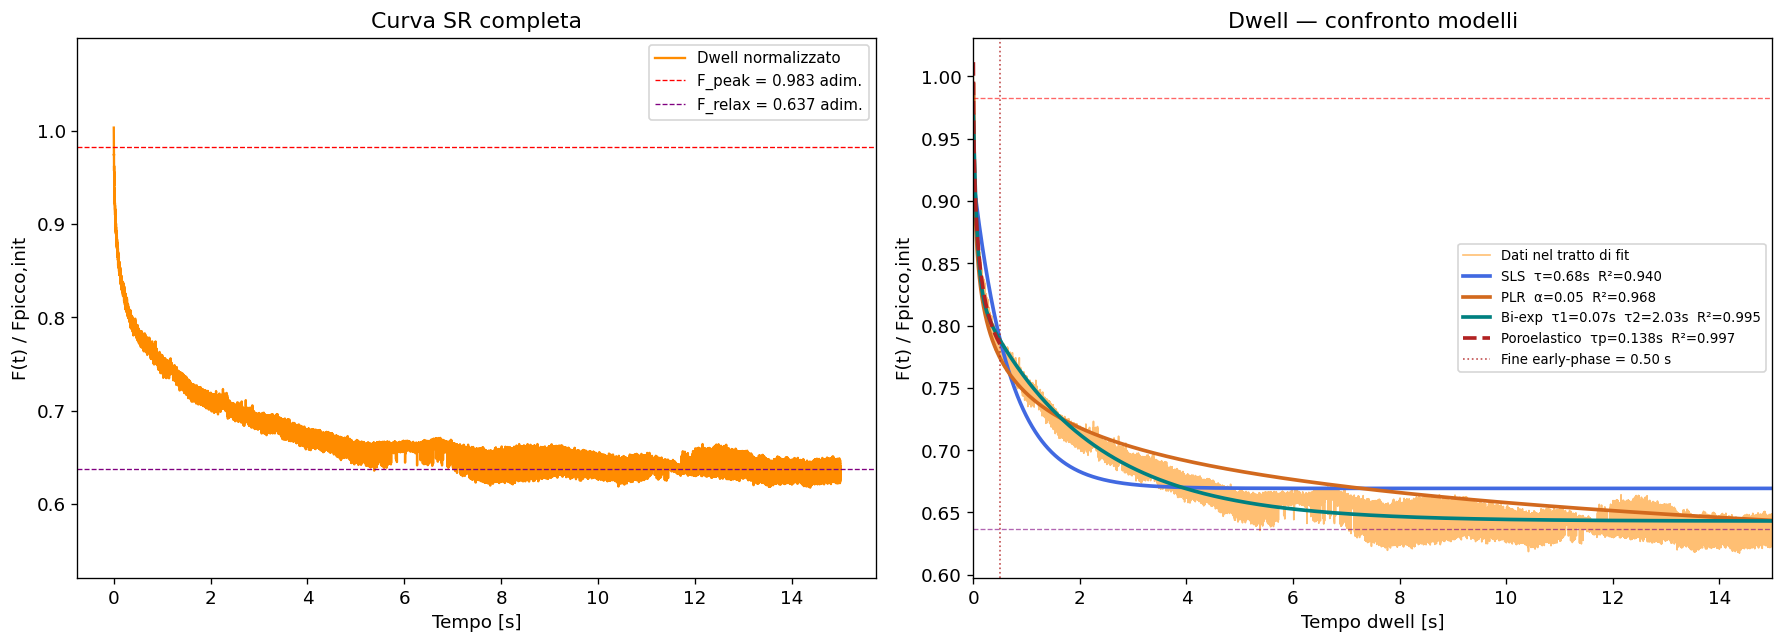

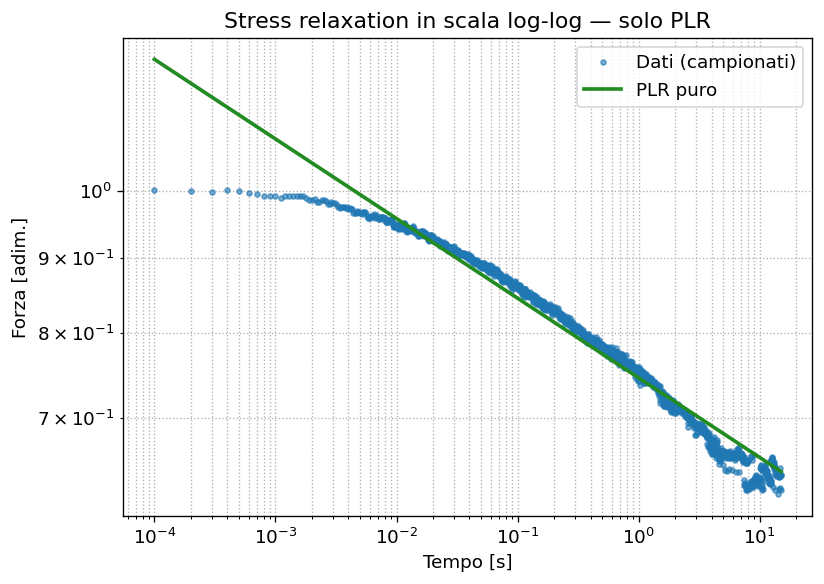

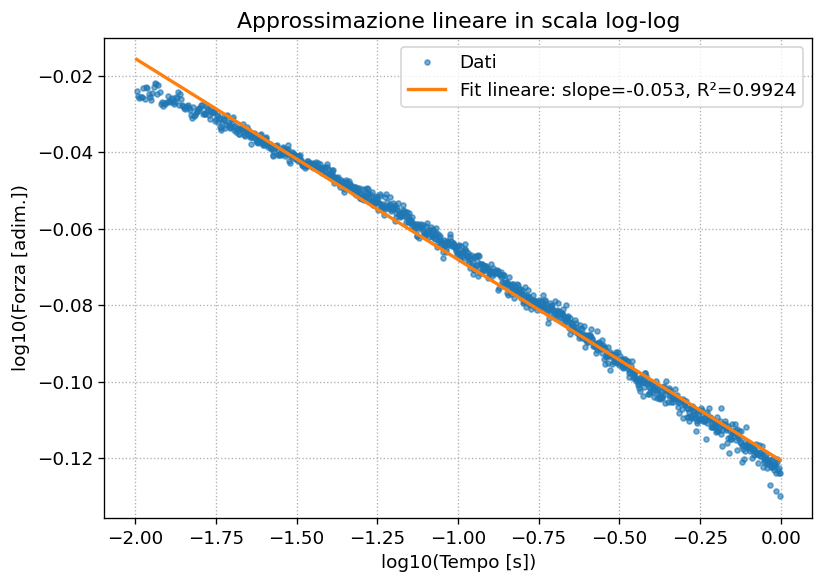


Tabella finale riassuntiva dei fit:


,rank,dominio,modello,parametri,R2,AIC,BIC,max_abs_corr,quality_score,migliore_bilanciato,warning
0,1,early-phase,Bi-exp GM,"F∞=0.6430, A1=0.1402, τ1=0.0715 s, A2=0.1857, ...",0.9820,-9864.3119,-9839.7532,0.7081,4.0,True,nessun warning critico
1,2,early-phase,Poroelastico,"F∞=0.7453, A=0.2662, τp=0.1380 s",0.9973,-11760.6626,-11745.9274,0.9655,5.0,False,parametri fortemente correlati (max|corr|=0.966)
2,3,early-phase,SLS,"F∞=0.6693, A=0.2483, τ=0.6850 s",0.7699,-7308.8047,-7294.0695,0.6731,6.0,False,nessun warning critico
3,4,early-phase,PLR puro,"F0=0.7924, t0=0.3237 s, α=0.0542",0.8504,-7737.7333,-7723.0010,1.0000,8.5,False,parametri fortemente correlati (max|corr|=1.00...
4,1,globale,Bi-exp GM,"F∞=0.6430, A1=0.1402, τ1=0.0715 s, A2=0.1857, ...",0.9947,-18231.7713,-18204.1297,0.7081,2.5,True,nessun warning critico
5,2,globale,SLS,"F∞=0.6693, A=0.2483, τ=0.6850 s",0.9400,-13719.0545,-13702.4695,0.6731,4.5,False,nessun warning critico
6,3,globale,PLR puro,"F0=0.7924, t0=0.3237 s, α=0.0542",0.9676,-14857.5438,-14840.9604,1.0000,7.0,False,parametri fortemente correlati (max|corr|=1.00...



✅ File medio usato per l'analisi: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR/cell5_SR-0000-media-norm.csv
✅ Report unico con 3 grafici + tabella salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/270326/cell05/SR/cell5_SR-0000-media-norm_sr_report_unico.pdf


In [ ]:
# 4. Analisi finale: solo file medio, 3 grafici e una tabella riassuntiva unica

from matplotlib.backends.backend_pdf import PdfPages

# --- Dati base ---
t = sr['t_pause']
Ft = sr['force_pause']
t_max = float(t[-1])
force_scale = sr['force_scale']
force_unit = sr['force_unit']
force_axis_label = sr['force_axis_label']
save_dir = os.path.dirname(os.path.abspath(data_dir))
base_name = os.path.splitext(os.path.basename(data_dir))[0]

# --- Indicatori semplici di rilassamento ---
avg_pts = 50
F_peak = float(np.mean(Ft[:avg_pts]))
F_relax = float(np.mean(Ft[-avg_pts:]))
delta_F = F_peak - F_relax
delta_F_pct = 100.0 * delta_F / F_peak if abs(F_peak) > 1e-12 else np.nan

print("=" * 45)
print(f"  F_peak            = {F_peak * force_scale:>10.4f}  {force_unit}")
print(f"  F_relax (plateau) = {F_relax * force_scale:>10.4f}  {force_unit}")
print(f"  ΔF  (assoluto)    = {delta_F * force_scale:>10.4f}  {force_unit}")
print(f"  ΔF% (relativo)    = {delta_F_pct:>10.2f}  %")
print("=" * 45)

# --- Utility ---
def r2(y, y_pred):
    y = np.asarray(y, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def information_criteria(y, y_pred, n_params):
    mask = np.isfinite(y) & np.isfinite(y_pred)
    y_valid = np.asarray(y)[mask]
    y_pred_valid = np.asarray(y_pred)[mask]
    n_obs = len(y_valid)
    if n_obs <= n_params:
        return float('nan'), float('nan')
    rss = np.sum((y_valid - y_pred_valid) ** 2)
    rss = max(rss, np.finfo(float).eps)
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return aic, bic


def build_fit_diagnostics(model_key, popt, pcov, param_names):
    diag = {
        'param_names': list(param_names),
        'stderr': {},
        'rel_err_pct': {},
        'max_abs_corr': float('nan'),
        'warnings': [],
    }
    if popt is None:
        diag['warnings'].append('fit non disponibile')
        return diag
    if pcov is None:
        diag['warnings'].append('covarianza non disponibile')
        return diag

    pcov = np.asarray(pcov, dtype=float)
    if pcov.ndim != 2 or pcov.shape[0] != pcov.shape[1] or not np.all(np.isfinite(pcov)):
        diag['warnings'].append('covarianza non valida o incompleta')
        return diag

    var = np.diag(pcov)
    stderr = np.sqrt(np.clip(var, 0, np.inf))
    for name, val, err in zip(param_names, popt, stderr):
        diag['stderr'][name] = float(err)
        if np.isfinite(val) and abs(val) > 1e-12 and np.isfinite(err):
            diag['rel_err_pct'][name] = float(abs(err / val) * 100)
        else:
            diag['rel_err_pct'][name] = None

    denom = np.sqrt(np.outer(np.clip(var, 0, np.inf), np.clip(var, 0, np.inf)))
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = pcov / denom

    if corr.shape[0] > 1:
        off_diag = corr[~np.eye(corr.shape[0], dtype=bool)]
        finite_off_diag = off_diag[np.isfinite(off_diag)]
        if finite_off_diag.size:
            diag['max_abs_corr'] = float(np.max(np.abs(finite_off_diag)))
            if diag['max_abs_corr'] > 0.95:
                diag['warnings'].append(f"parametri fortemente correlati (max|corr|={diag['max_abs_corr']:.3f})")

    noisy_params = [k for k, v in diag['rel_err_pct'].items() if v is not None and v > 50]
    if noisy_params:
        diag['warnings'].append('incertezza elevata per: ' + ', '.join(noisy_params))

    if model_key == 'bi' and len(popt) >= 5:
        tau1 = abs(float(popt[2]))
        tau2 = abs(float(popt[4]))
        tau_fast = min(tau1, tau2)
        tau_slow = max(tau1, tau2)
        tau_ratio = tau_slow / tau_fast if tau_fast > 1e-12 else np.inf
        diag['tau_ratio'] = float(tau_ratio)
        if tau_ratio < 3:
            diag['warnings'].append(f'tau1 e tau2 poco separati (rapporto={tau_ratio:.2f})')

    if not diag['warnings']:
        diag['warnings'].append('nessun warning critico')
    return diag


def choose_best_model(metrics, criterion='BIC'):
    valid = {
        key: val for key, val in metrics.items()
        if np.isfinite(val.get('R2', np.nan)) and np.isfinite(val.get(criterion, np.nan))
    }
    if not valid:
        return None
    return min(valid, key=lambda key: (valid[key][criterion], -valid[key]['R2']))


def choose_best_r2(metrics):
    valid = {key: val for key, val in metrics.items() if np.isfinite(val.get('R2', np.nan))}
    if not valid:
        return None
    return max(valid, key=lambda key: valid[key]['R2'])


def build_ordered_model_table(metrics_dict, diagnostics_dict, model_keys, domain_label):
    rows = []
    for key in model_keys:
        met = metrics_dict.get(key, {})
        diag = diagnostics_dict.get(key, {})
        r2v = met.get('R2', np.nan)
        aicv = met.get('AIC', np.nan)
        bicv = met.get('BIC', np.nan)
        corrv = diag.get('max_abs_corr', np.nan)
        warnings_list = [w for w in diag.get('warnings', []) if w and w != 'nessun warning critico']

        if not (np.isfinite(r2v) and np.isfinite(aicv) and np.isfinite(bicv)):
            continue

        if not np.isfinite(corrv):
            corr_penalty = 1
        elif corrv >= 0.95:
            corr_penalty = 3
        elif corrv >= 0.85:
            corr_penalty = 2
        elif corrv >= 0.70:
            corr_penalty = 1
        else:
            corr_penalty = 0

        rows.append({
            'model_key': key,
            'modello': model_label_map.get(key, key),
            'dominio': domain_label,
            'R2': float(r2v),
            'AIC': float(aicv),
            'BIC': float(bicv),
            'max_abs_corr': float(corrv) if np.isfinite(corrv) else np.nan,
            'corr_penalty': int(corr_penalty),
            'warning_count': int(len(warnings_list)),
            'warning': ' | '.join(warnings_list) if warnings_list else 'nessun warning critico',
        })

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df['rank_BIC'] = df['BIC'].rank(method='dense', ascending=True)
    df['rank_R2'] = df['R2'].rank(method='dense', ascending=False)
    df['quality_score'] = df['rank_BIC'] + 0.5 * df['rank_R2'] + df['corr_penalty'] + 0.5 * df['warning_count']
    df = df.sort_values(
        ['quality_score', 'rank_BIC', 'rank_R2', 'max_abs_corr'],
        ascending=[True, True, True, True]
    ).reset_index(drop=True)
    df.insert(0, 'rank', np.arange(1, len(df) + 1))
    df['migliore_bilanciato'] = df['rank'] == 1
    return df


def mono_exp(t, F_inf, A, tau):
    return F_inf + A * np.exp(-t / tau)


def plr(t, F0, t0_plr, alpha):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = F0 * (t / t0_plr) ** (-alpha)
    return np.where(t > 0, result, np.nan)


def bi_exp(t, F_inf, A1, tau1, A2, tau2):
    return F_inf + A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2)


def poro_relax(t, F_inf, A, tau_p):
    t_clip = np.maximum(t, 0.0)
    return F_inf + A * np.exp(-np.sqrt(t_clip / tau_p))


def format_parametri(model_key, params):
    if params is None:
        return 'n.d.'
    if model_key == 'mono':
        return f"F∞={params[0]:.4f}, A={params[1]:.4f}, τ={params[2]:.4f} s"
    if model_key == 'plr':
        return f"F0={params[0]:.4f}, t0={params[1]:.4f} s, α={params[2]:.4f}"
    if model_key == 'bi':
        return f"F∞={params[0]:.4f}, A1={params[1]:.4f}, τ1={params[2]:.4f} s, A2={params[3]:.4f}, τ2={params[4]:.4f} s"
    if model_key == 'poro':
        return f"F∞={params[0]:.4f}, A={params[1]:.4f}, τp={params[2]:.4f} s"
    return 'n.d.'


# --- Downsampling per i fit ---
N_fit = 3000
if len(t) > N_fit:
    idx = np.unique(np.concatenate([
        [0],
        np.round(np.logspace(0, np.log10(len(t) - 1), N_fit - 1)).astype(int)
    ]))
    idx = np.clip(idx, 0, len(t) - 1)
    t_fit = t[idx]
    Ft_fit = Ft[idx]
else:
    t_fit = t
    Ft_fit = Ft

Ft_fit_scaled = Ft_fit * force_scale
t_fit_log = t_fit[t_fit > 0]
Ft_fit_log = Ft_fit[t_fit > 0]

fit_results = {}
fit_covariances = {}
fit_diagnostics = {}
poro_fit_max_time = 0.5
t_poro_stop = min(poro_fit_max_time, t_max)
model_label_map = {
    'mono': 'SLS',
    'plr': 'PLR puro',
    'bi': 'Bi-exp GM',
    'poro': 'Poroelastico',
}

print(f"Punti usati per il fit globale: {len(t_fit)} / {len(t)}  |  unità forza: {force_unit}")
print(f"Fit poroelastico limitato a: 0 - {t_poro_stop:.2f} s")

# --- Fit mono-exp ---
try:
    p0 = [F_relax * force_scale, (F_peak - F_relax) * force_scale, max(t_max / 5, 1e-4)]
    popt_m, pcov_m = curve_fit(
        mono_exp,
        t_fit,
        Ft_fit_scaled,
        p0=p0,
        maxfev=10000,
        bounds=([-np.inf, 0, 1e-4], [np.inf, np.inf, np.inf]),
    )
    r2_m = r2(Ft_fit_scaled, mono_exp(t_fit, *popt_m))
    fit_results['mono'] = popt_m
    fit_covariances['mono'] = pcov_m
    print(f"[1] Mono-exp (SLS): τ = {popt_m[2]:.3f} s   F_inf = {popt_m[0]:.4f} {force_unit}   R² = {r2_m:.4f}")
except Exception as e:
    popt_m, pcov_m, r2_m = None, None, float('nan')
    fit_results['mono'] = None
    fit_covariances['mono'] = None
    print(f"[1] Mono-exp fallito: {e}")

# --- Fit PLR ---
try:
    mask_pos = t_fit > 0
    t_plr = t_fit[mask_pos]
    y_plr = Ft_fit_scaled[mask_pos]
    sign_plr = -1.0 if np.nanmedian(y_plr) < 0 else 1.0
    y_plr_abs = sign_plr * y_plr
    mask_valid_plr = np.isfinite(y_plr_abs) & (y_plr_abs > 0)
    if not np.any(mask_valid_plr):
        raise ValueError('nessun punto positivo valido per PLR dopo correzione di segno')

    t_plr = t_plr[mask_valid_plr]
    y_plr_abs = y_plr_abs[mask_valid_plr]
    p0 = [max(float(y_plr_abs[0]), 1e-6), max(float(t_plr[0]), 1e-6), 0.2]

    popt_plr_abs, pcov_plr_abs = curve_fit(
        plr,
        t_plr,
        y_plr_abs,
        p0=p0,
        maxfev=20000,
        bounds=([0, 1e-6, 0.01], [np.inf, np.inf, 2.0]),
    )
    y_pred_abs = plr(t_plr, *popt_plr_abs)
    r2_plr = r2(y_plr_abs, y_pred_abs)
    popt_plr = np.array([sign_plr * popt_plr_abs[0], popt_plr_abs[1], popt_plr_abs[2]])
    fit_results['plr'] = popt_plr
    fit_covariances['plr'] = pcov_plr_abs
    print(f"[2] PLR puro: α = {popt_plr[2]:.3f}   t0 = {popt_plr[1]:.4f} s   F0 = {popt_plr[0]:.4f} {force_unit}   R² = {r2_plr:.4f}")
except Exception as e:
    popt_plr, pcov_plr_abs, r2_plr = None, None, float('nan')
    fit_results['plr'] = None
    fit_covariances['plr'] = None
    print(f"[2] PLR puro fallito: {e}")

# --- Fit bi-exp ---
try:
    p0 = [
        F_relax * force_scale,
        (F_peak - F_relax) * force_scale * 0.6,
        max(t_max / 20, 1e-4),
        (F_peak - F_relax) * force_scale * 0.4,
        max(t_max / 3, 1e-4),
    ]
    lb = [-np.inf, 0, 1e-4, 0, 1e-4]
    ub = [np.inf, np.inf, t_max, np.inf, np.inf]
    popt_b, pcov_b = curve_fit(bi_exp, t_fit, Ft_fit_scaled, p0=p0, maxfev=30000, bounds=(lb, ub))
    if popt_b[2] > popt_b[4]:
        popt_b = np.array([popt_b[0], popt_b[3], popt_b[4], popt_b[1], popt_b[2]])
        if pcov_b is not None and np.shape(pcov_b) == (5, 5):
            order = [0, 3, 4, 1, 2]
            pcov_b = pcov_b[np.ix_(order, order)]
    r2_b = r2(Ft_fit_scaled, bi_exp(t_fit, *popt_b))
    fit_results['bi'] = popt_b
    fit_covariances['bi'] = pcov_b
    print(f"[3] Bi-exp (GM): τ1 = {popt_b[2]:.3f} s   τ2 = {popt_b[4]:.3f} s   F_inf = {popt_b[0]:.4f} {force_unit}   R² = {r2_b:.4f}")
except Exception as e:
    popt_b, pcov_b, r2_b = None, None, float('nan')
    fit_results['bi'] = None
    fit_covariances['bi'] = None
    print(f"[3] Bi-exp fallito: {e}")

# --- Fit poroelastico sui primi 0.5 s ---
early_mask = (t_fit >= 0.0) & (t_fit <= t_poro_stop)
if np.sum(early_mask) < 20:
    raise ValueError(f"Troppi pochi punti disponibili entro {t_poro_stop:.2f} s per il fit poroelastico")

t_early = t_fit[early_mask]
F_early = Ft_fit_scaled[early_mask]
print(f"Intervallo early-phase: 0 - {t_early[-1]:.3f} s  ({len(t_early)} punti)")

try:
    p0 = [F_relax * force_scale, (F_peak - F_relax) * force_scale, max(t_early[-1] / 4, 1e-4)]
    lb = [-np.inf, 0, 1e-6]
    ub = [np.inf, np.inf, max(t_early[-1] * 10, 1e-3)]
    popt_poro, pcov_poro = curve_fit(
        poro_relax,
        t_early,
        F_early,
        p0=p0,
        bounds=(lb, ub),
        maxfev=30000,
    )
    r2_poro_early = r2(F_early, poro_relax(t_early, *popt_poro))
    fit_results['poro'] = popt_poro
    fit_covariances['poro'] = pcov_poro
    print(f"[4] Poroelastico: τp = {popt_poro[2]:.4f} s   F_inf = {popt_poro[0]:.4f} {force_unit}   R²(early) = {r2_poro_early:.4f}")
except Exception as e:
    popt_poro, pcov_poro, r2_poro_early = None, None, float('nan')
    fit_results['poro'] = None
    fit_covariances['poro'] = None
    print(f"[4] Poroelastico fallito: {e}")

# --- Metriche e diagnostica ---
global_metrics = {k: {'R2': np.nan, 'AIC': np.nan, 'BIC': np.nan} for k in ['mono', 'plr', 'bi', 'poro']}
early_metrics = {k: {'R2': np.nan, 'AIC': np.nan, 'BIC': np.nan} for k in ['mono', 'plr', 'bi', 'poro']}

if fit_results.get('mono') is not None:
    pred = mono_exp(t_fit, *fit_results['mono'])
    aic, bic = information_criteria(Ft_fit_scaled, pred, 3)
    global_metrics['mono'] = {'R2': r2_m, 'AIC': aic, 'BIC': bic}
    pred_e = mono_exp(t_early, *fit_results['mono'])
    aic, bic = information_criteria(F_early, pred_e, 3)
    early_metrics['mono'] = {'R2': r2(F_early, pred_e), 'AIC': aic, 'BIC': bic}

if fit_results.get('plr') is not None:
    pred = plr(t_fit, *fit_results['plr'])
    mask = np.isfinite(pred)
    aic, bic = information_criteria(Ft_fit_scaled[mask], pred[mask], 3)
    global_metrics['plr'] = {'R2': r2_plr, 'AIC': aic, 'BIC': bic}
    pred_e = plr(t_early, *fit_results['plr'])
    mask = np.isfinite(pred_e)
    if np.any(mask):
        aic, bic = information_criteria(F_early[mask], pred_e[mask], 3)
        early_metrics['plr'] = {'R2': r2(F_early[mask], pred_e[mask]), 'AIC': aic, 'BIC': bic}

if fit_results.get('bi') is not None:
    pred = bi_exp(t_fit, *fit_results['bi'])
    aic, bic = information_criteria(Ft_fit_scaled, pred, 5)
    global_metrics['bi'] = {'R2': r2_b, 'AIC': aic, 'BIC': bic}
    pred_e = bi_exp(t_early, *fit_results['bi'])
    aic, bic = information_criteria(F_early, pred_e, 5)
    early_metrics['bi'] = {'R2': r2(F_early, pred_e), 'AIC': aic, 'BIC': bic}

if fit_results.get('poro') is not None:
    pred = poro_relax(t_early, *fit_results['poro'])
    aic, bic = information_criteria(F_early, pred, 3)
    global_metrics['poro'] = {'R2': r2_poro_early, 'AIC': aic, 'BIC': bic}
    early_metrics['poro'] = {'R2': r2_poro_early, 'AIC': aic, 'BIC': bic}

param_names_map = {
    'mono': ['F_inf', 'A', 'tau'],
    'plr': ['F0', 't0', 'alpha'],
    'bi': ['F_inf', 'A1', 'tau1', 'A2', 'tau2'],
    'poro': ['F_inf', 'A', 'tau_p'],
}
for key, names in param_names_map.items():
    fit_diagnostics[key] = build_fit_diagnostics(key, fit_results.get(key), fit_covariances.get(key), names)

global_comp_metrics = {k: global_metrics[k] for k in ['mono', 'plr', 'bi']}
early_comp_metrics = {k: early_metrics[k] for k in ['mono', 'plr', 'bi', 'poro']}
fit_ranking_global_df = build_ordered_model_table(global_comp_metrics, fit_diagnostics, ['mono', 'plr', 'bi'], 'globale')
fit_ranking_early_df = build_ordered_model_table(early_comp_metrics, fit_diagnostics, ['mono', 'plr', 'bi', 'poro'], 'early-phase')
fit_ranking_df = pd.concat([fit_ranking_global_df, fit_ranking_early_df], ignore_index=True)

model_recommendations = {
    'best_global_bic': choose_best_model(global_comp_metrics, 'BIC'),
    'best_global_aic': choose_best_model(global_comp_metrics, 'AIC'),
    'best_global_r2': choose_best_r2(global_comp_metrics),
    'best_global_balanced': fit_ranking_global_df.iloc[0]['model_key'] if not fit_ranking_global_df.empty else None,
    'best_early_bic': choose_best_model(early_comp_metrics, 'BIC'),
    'best_early_aic': choose_best_model(early_comp_metrics, 'AIC'),
    'best_early_r2': choose_best_r2(early_comp_metrics),
    'best_early_balanced': fit_ranking_early_df.iloc[0]['model_key'] if not fit_ranking_early_df.empty else None,
}

print("\nMetriche nella sola fase iniziale (0 → 0.5 s):")
for key in ['mono', 'plr', 'bi', 'poro']:
    met = early_metrics[key]
    if np.isfinite(met['R2']):
        print(f"  {model_label_map[key]:12s}: R²={met['R2']:.4f}   AIC={met['AIC']:.2f}   BIC={met['BIC']:.2f}")
    else:
        print(f"  {model_label_map[key]:12s}: n.d.")

print("\nDiagnostica automatica dei fit:")
for key in ['mono', 'plr', 'bi', 'poro']:
    diag = fit_diagnostics[key]
    corr = diag.get('max_abs_corr', np.nan)
    corr_txt = f"{corr:.3f}" if np.isfinite(corr) else 'n.d.'
    warn_text = '; '.join(diag.get('warnings', []))
    print(f"  {model_label_map[key]:12s}: max|corr|={corr_txt}   {warn_text}")

print("\nSelezione automatica del modello:")
print("  (nota: il poroelastico viene confrontato solo nella early-phase 0–0.5 s)")
if model_recommendations['best_global_balanced'] is not None:
    print(f"  • Miglior modello globale bilanciato: {model_label_map[model_recommendations['best_global_balanced']]}")
if model_recommendations['best_early_balanced'] is not None:
    print(f"  • Miglior modello early-phase bilanciato: {model_label_map[model_recommendations['best_early_balanced']]}")

# --- Tabella finale unica ---
summary_rows = []
for domain_label, metrics_source, keys in [
    ('globale', global_comp_metrics, ['mono', 'plr', 'bi']),
    ('early-phase', early_comp_metrics, ['mono', 'plr', 'bi', 'poro']),
]:
    for key in keys:
        met = metrics_source.get(key, {})
        if not np.isfinite(met.get('R2', np.nan)):
            continue
        rank_row = fit_ranking_df[(fit_ranking_df['dominio'] == domain_label) & (fit_ranking_df['model_key'] == key)]
        rank_val = int(rank_row['rank'].iloc[0]) if not rank_row.empty else np.nan
        quality_score = float(rank_row['quality_score'].iloc[0]) if not rank_row.empty else np.nan
        best_flag = bool(rank_row['migliore_bilanciato'].iloc[0]) if not rank_row.empty else False
        summary_rows.append({
            'rank': rank_val,
            'dominio': domain_label,
            'modello': model_label_map[key],
            'parametri': format_parametri(key, fit_results.get(key)),
            'R2': float(met['R2']),
            'AIC': float(met['AIC']),
            'BIC': float(met['BIC']),
            'max_abs_corr': float(fit_diagnostics.get(key, {}).get('max_abs_corr', np.nan)) if np.isfinite(fit_diagnostics.get(key, {}).get('max_abs_corr', np.nan)) else np.nan,
            'quality_score': quality_score,
            'migliore_bilanciato': best_flag,
            'warning': ' | '.join(fit_diagnostics.get(key, {}).get('warnings', [])),
        })

tabella_finale_df = pd.DataFrame(summary_rows)
tabella_finale_df = tabella_finale_df.sort_values(['dominio', 'rank']).reset_index(drop=True)
tabella_finale_display_df = tabella_finale_df.copy()
for col in ['R2', 'AIC', 'BIC', 'max_abs_corr', 'quality_score']:
    tabella_finale_display_df[col] = tabella_finale_display_df[col].round(4)

# --- Grafico 1: curva completa + confronto modelli ---
fig_main, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]

if not sr['is_normalized'] and len(sr['t_ext']) > 0 and len(sr['t_ret']) > 0:
    t_ext_plot = sr['t_ext']
    t_pause_plot = t_ext_plot[-1] + sr['t_pause']
    t_ret_plot = t_pause_plot[-1] + sr['t_ret']
    ax.plot(t_ext_plot, sr['force_ext'] * force_scale, color='steelblue', lw=1.2, label='Avvicinamento')
    ax.plot(t_pause_plot, sr['force_pause'] * force_scale, color='darkorange', lw=1.2, label='Dwell (SR)')
    ax.plot(t_ret_plot, sr['force_ret'] * force_scale, color='seagreen', lw=1.2, label='Retract')
    f_rel = np.concatenate([sr['force_pause'] * force_scale, sr['force_ret'] * force_scale])
else:
    ax.plot(sr['t_pause'], sr['force_pause'] * force_scale, color='darkorange', lw=1.4,
            label='Dwell normalizzato' if sr['is_normalized'] else 'Dwell (SR)')
    f_rel = sr['force_pause'] * force_scale

ax.axhline(F_peak * force_scale, color='red', ls='--', lw=0.8,
           label=f'F_peak = {F_peak * force_scale:.3f} {force_unit}')
ax.axhline(F_relax * force_scale, color='purple', ls='--', lw=0.8,
           label=f'F_relax = {F_relax * force_scale:.3f} {force_unit}')
ax.set_xlabel('Tempo [s]')
ax.set_ylabel(force_axis_label)
ax.set_title('Curva SR completa')
ax.legend(fontsize=9)

f_lo, f_hi = np.nanmin(f_rel), np.nanmax(f_rel)
margin = (f_hi - f_lo) * 0.25 if f_hi > f_lo else 0.2
ax.set_ylim(f_lo - margin, f_hi + margin)

ax2 = axes[1]
data_mask = (sr['t_pause'] >= t_fit[0]) & (sr['t_pause'] <= t_fit[-1])
ax2.plot(sr['t_pause'][data_mask], sr['force_pause'][data_mask] * force_scale,
         color='darkorange', lw=1.0, alpha=0.55, label='Dati nel tratto di fit')

t_fine = np.linspace(t_fit[0], t_fit[-1], 3000)
t_fine_poro = np.linspace(t_early[0], t_early[-1], 800)
model_specs = [
    ('mono', 'royalblue', '-', t_fine, lambda tt, p: mono_exp(tt, *p),
     lambda p, rv: f'SLS  τ={p[2]:.2f}s  R²={rv:.3f}'),
    ('plr', 'chocolate', '-', t_fine, lambda tt, p: plr(tt, *p),
     lambda p, rv: f'PLR  α={p[2]:.2f}  R²={rv:.3f}'),
    ('bi', 'teal', '-', t_fine, lambda tt, p: bi_exp(tt, *p),
     lambda p, rv: f'Bi-exp  τ1={p[2]:.2f}s  τ2={p[4]:.2f}s  R²={rv:.3f}'),
    ('poro', 'firebrick', '--', t_fine_poro, lambda tt, p: poro_relax(tt, *p),
     lambda p, rv: f'Poroelastico  τp={p[2]:.3f}s  R²={rv:.3f}'),
]
r2_map = {'mono': r2_m, 'plr': r2_plr, 'bi': r2_b, 'poro': early_metrics['poro']['R2']}

for key, color, ls, t_plot, fn, lbl_fn in model_specs:
    if fit_results.get(key) is not None:
        y_plot = fn(t_plot, fit_results[key])
        mask_plot = np.isfinite(y_plot)
        ax2.plot(t_plot[mask_plot], y_plot[mask_plot], ls=ls, color=color, lw=2.2,
                 label=lbl_fn(fit_results[key], r2_map.get(key, np.nan)))

ax2.axhline(F_peak * force_scale, color='red', ls='--', lw=0.8, alpha=0.6)
ax2.axhline(F_relax * force_scale, color='purple', ls='--', lw=0.8, alpha=0.6)
ax2.axvline(t_early[-1], color='firebrick', ls=':', lw=1.0, alpha=0.8,
            label=f'Fine early-phase = {t_early[-1]:.2f} s')
ax2.set_xlim(t_fit[0], t_fit[-1])
ax2.set_xlabel('Tempo dwell [s]')
ax2.set_ylabel(force_axis_label)
ax2.set_title('Dwell — confronto modelli')
ax2.legend(fontsize=8, loc='best')
fig_main.tight_layout()
plt.show()

# --- Grafico 2: log-log con solo PLR ---
fig_log = None
if len(t_fit_log) > 0:
    fig_log, ax_log = plt.subplots(figsize=(7, 5))
    ax_log.loglog(t_fit_log, Ft_fit_log * force_scale, 'o', ms=3, alpha=0.6, label='Dati (campionati)')
    if popt_plr is not None:
        ax_log.loglog(t_fit_log, plr(t_fit_log, *popt_plr), '-', lw=2.2, color='forestgreen', label='PLR puro')
    ax_log.set_xlabel('Tempo [s]')
    ax_log.set_ylabel(f'Forza [{force_unit}]')
    ax_log.set_title('Stress relaxation in scala log-log — solo PLR')
    ax_log.legend()
    ax_log.grid(True, which='both', ls=':')
    fig_log.tight_layout()
    plt.show()

# --- Grafico 3: approssimazione lineare log-log ---
fig_line = None
mask_ll = (t_fit_log > 1e-2) & (t_fit_log <= 1.0) & np.isfinite(Ft_fit_log) & (Ft_fit_log > 0)
if np.sum(mask_ll) >= 5:
    xlog = np.log10(t_fit_log[mask_ll])
    ylog = np.log10(Ft_fit_log[mask_ll] * force_scale)
    coeff = np.polyfit(xlog, ylog, 1)
    slope, intercept = float(coeff[0]), float(coeff[1])
    ylog_pred = slope * xlog + intercept
    r2_loglog = r2_score(ylog, ylog_pred)

    fig_line, ax_line = plt.subplots(figsize=(7, 5))
    ax_line.plot(xlog, ylog, 'o', ms=3, alpha=0.6, label='Dati')
    ax_line.plot(xlog, ylog_pred, '-', lw=2, label=f'Fit lineare: slope={slope:.3f}, R²={r2_loglog:.4f}')
    ax_line.set_xlabel('log10(Tempo [s])')
    ax_line.set_ylabel(f'log10(Forza [{force_unit}])')
    ax_line.set_title('Approssimazione lineare in scala log-log')
    ax_line.legend()
    ax_line.grid(True, ls=':')
    fig_line.tight_layout()
    plt.show()

# --- Tabella finale a video ---
print("\nTabella finale riassuntiva dei fit:")
display(tabella_finale_display_df)

# --- Salvataggio: UN SOLO formato (PDF) + file medio già generato sopra ---
report_unico_path = os.path.join(save_dir, f"{base_name}_sr_report_unico.pdf")

if save_outputs:
    legacy_outputs = [
        f"{base_name}_sr_fit_results.json",
        f"{base_name}_sr_fit.png",
        f"{base_name}_sr_report.pdf",
        f"{base_name}_sr_fit_ranking.csv",
        f"{base_name}_sr_fit_ranking.json",
        f"{base_name}_sr_loglog_points.png",
        f"{base_name}_sr_loglog_linear_fit.png",
        f"{base_name}_sr_loglog_linear_fit.json",
        "sr_mean_file_summary.csv",
        "sr_mean_file_summary.json",
    ]
    for file_name in legacy_outputs:
        file_path = os.path.join(save_dir, file_name)
        if os.path.exists(file_path):
            try:
                os.remove(file_path)
            except OSError:
                pass

    with PdfPages(report_unico_path) as pdf:
        pdf.savefig(fig_main, bbox_inches='tight')
        if fig_log is not None:
            pdf.savefig(fig_log, bbox_inches='tight')
        if fig_line is not None:
            pdf.savefig(fig_line, bbox_inches='tight')

        fig_tab = plt.figure(figsize=(15, max(4.5, 2.0 + 0.45 * len(tabella_finale_display_df))))
        ax_tab = fig_tab.add_axes([0.02, 0.02, 0.96, 0.96])
        ax_tab.axis('off')
        summary_lines = [
            f"File medio analizzato: {os.path.basename(data_dir)}",
            f"Durata: {t_max:.2f} s   |   Punti: {len(t)}",
            f"F_peak: {F_peak * force_scale:.4f} {force_unit}",
            f"F_relax: {F_relax * force_scale:.4f} {force_unit}",
            f"ΔF: {delta_F * force_scale:.4f} {force_unit} ({delta_F_pct:.2f}%)",
            f"Miglior fit globale bilanciato: {model_label_map.get(model_recommendations.get('best_global_balanced'), 'n.d.')}",
            f"Miglior fit early-phase bilanciato: {model_label_map.get(model_recommendations.get('best_early_balanced'), 'n.d.')}",
        ]
        ax_tab.text(0.01, 0.98, "\n".join(summary_lines), ha='left', va='top', fontsize=11)

        table = ax_tab.table(
            cellText=tabella_finale_display_df.astype(str).values,
            colLabels=tabella_finale_display_df.columns,
            cellLoc='center',
            colLoc='center',
            bbox=[0.0, 0.02, 1.0, 0.72],
        )
        table.auto_set_font_size(False)
        table.set_fontsize(7.5)
        table.scale(1, 1.3)
        pdf.savefig(fig_tab, bbox_inches='tight')
        plt.close(fig_tab)

    print(f"\n✅ File medio usato per l'analisi: {data_dir}")
    print(f"✅ Report unico con 3 grafici + tabella salvato in: {report_unico_path}")

if open_output_folder:
    target_to_open = report_unico_path if os.path.exists(report_unico_path) else save_dir
    os.system(f'open "{target_to_open}"')


In [ ]:
# Controllo rapido del salvataggio su disco
import os
from matplotlib.backends.backend_pdf import PdfPages

print('save_dir =', save_dir)
print('report_unico_path =', report_unico_path)

with open(os.path.join(save_dir, 'test_scrittura.txt'), 'w') as f:
    f.write('ok')

fig_test, ax_test = plt.subplots(figsize=(3, 2))
ax_test.plot([0, 1], [0, 1])
ax_test.set_title('test')
with PdfPages(report_unico_path) as pdf_test:
    pdf_test.savefig(fig_test, bbox_inches='tight')
plt.close(fig_test)

print('esiste txt?', os.path.exists(os.path.join(save_dir, 'test_scrittura.txt')))
print('esiste PDF?', os.path.exists(report_unico_path))
print('contenuto cartella:')
for name in sorted(os.listdir(save_dir)):
    print(' -', name)